In [1]:
import pandas as pd
import numpy as np

# Load your data
pma = pd.read_csv('D:\MS\Summer-25\Spark\Population Estimates\csv_pma\psam_p25.csv')
hma = pd.read_csv('D:\MS\Summer-25\Spark\Population Estimates\csv_hma\psam_h25.csv')

merged_ma = pd.merge(pma, hma, on="SERIALNO")
print(f"Merged dataset shape: {merged_ma.shape}")

Merged dataset shape: (73126, 527)


In [241]:

def derive_mom_loc_head(df):
    """
    Fixed version that uses the input dataframe parameter correctly
    """
    # Create a copy to avoid modifying original data
    result_df = df.copy()  # Use df parameter, not hardcoded merged_ma
    
    # Initialize MOM_LOC_HEAD column
    result_df['MOM_LOC_HEAD'] = None
    
    # Group by household (SERIALNO)
    for serialno, household in df.groupby('SERIALNO'):
        
        # Step 1: Find head of household (RELSHIPP == 20)
        head_records = household[household['RELSHIPP'] == 20]
        
        if len(head_records) == 0:
            # No head of household found, skip this household
            continue
        
        # Take first head if multiple (shouldn't happen in clean data)
        head = head_records.iloc[0]
        head_age = head['AGEP']
        head_sporder = head['SPORDER']
        
        # Step 3: Find mother candidates in same household
        candidates = household[
            (household['SEX'] == 2) # &  # Female
            # (household['AGEP'] <= head_age - 12)  # At least 12 years older than head
        ]
        
        if len(candidates) == 0:
            # No candidates found
            mom_sporder = 0
        else:
            # Step 4: Prioritize RELSHIPP == 29 (mother)
            mother_candidates = candidates[candidates['RELSHIPP'] == 29]
            
            if len(mother_candidates) > 0:
                # Found mother relationship, take first one
                mom_sporder = mother_candidates.iloc[0]['SPORDER']
            else:
                # No mother relationship found, take first candidate that fits age/sex criteria
                mom_sporder = 0
        
        # Assign MOM_LOC_HEAD to the head of household record
        household_mask = (result_df['SERIALNO'] == serialno) 
        result_df.loc[household_mask, 'MOM_LOC_HEAD'] = mom_sporder
    
    return result_df

# Run the function on your merged dataset
print("Processing MOM_LOC_HEAD...")
result_data = derive_mom_loc_head(merged_ma)

# Check the results
# print(f"Final dataset shape: {result_data.shape}")
# print("\nSample of results (heads of household only):")
# heads_sample = result_data[result_data['RELSHIPP'] == 20][['SERIALNO', 'SPORDER', 'AGEP', 'SEX', 'RELSHIPP', 'MOM_LOC_HEAD']].head(10)
# print(heads_sample)

# # Summary statistics
# print(f"\nSummary:")
# total_heads = len(result_data[result_data['RELSHIPP'] == 20])
# heads_with_mom = len(result_data[(result_data['RELSHIPP'] == 20) & (result_data['MOM_LOC_HEAD'].notna())])
# print(f"Total heads of household: {total_heads}")
# print(f"Heads with identified mothers: {heads_with_mom}")
# print(f"Percentage with mothers identified: {heads_with_mom/total_heads*100:.1f}%")



# heads_with_mothers = result_data[
#     (result_data['RELSHIPP'] == 20) & 
#     (result_data['MOM_LOC_HEAD'].notna())
# ]

# print(f"\nFound {len(heads_with_mothers)} heads of household with identified mothers")
# print(heads_with_mothers) 

Processing MOM_LOC_HEAD...


In [228]:
file_path = r'usa_00003.csv'

df = pd.read_csv(file_path)

df.head(10) 

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,MOMLOC,POPLOC,SPLOC,NCHILD,RELATE,RELATED,SEX,AGE,POVERTY,CBPOVERTY
0,2023,202301,1,2023010000113,6.0,2023000000011,41,280201,3,1,...,0,0,0,0,13,1301,2,86,0,0
1,2023,202301,2,2023010000180,27.0,2023000000021,41,10001,3,1,...,0,0,0,0,13,1301,1,60,0,0
2,2023,202301,3,2023010000181,47.0,2023000000031,41,40201,4,1,...,0,0,0,0,12,1270,1,20,0,0
3,2023,202301,4,2023010000250,11.0,2023000000041,41,270201,3,1,...,0,0,0,0,13,1301,2,13,0,0
4,2023,202301,5,2023010000340,57.0,2023000000051,41,280201,4,1,...,0,0,0,0,12,1270,1,18,0,0
5,2023,202301,6,2023010000364,52.0,2023000000061,41,120201,4,1,...,0,0,0,0,12,1270,1,19,0,0
6,2023,202301,7,2023010000493,43.0,2023000000071,41,180101,3,1,...,0,0,0,0,13,1301,1,37,0,0
7,2023,202301,8,2023010000537,1.0,2023000000081,41,140201,4,1,...,0,0,0,0,12,1270,1,71,0,107
8,2023,202301,9,2023010000558,3.0,2023000000091,41,140401,4,1,...,0,0,0,0,12,1270,2,75,0,69
9,2023,202301,10,2023010000796,41.0,2023000000101,41,280201,4,1,...,0,0,0,0,12,1270,2,19,0,0


In [229]:
def get_momloc_head(row, df):
    head = df[(df['SERIAL'] == row['SERIAL']) & (df['RELATE'] == 1)]
    if not head.empty:
        return int(head.iloc[0]['MOMLOC'])
    return None

df_mass = df[df['STATEICP'] == 3]
df_mass['MOMLOC_HEAD'] = df_mass.apply(lambda row: get_momloc_head(row, df_mass), axis=1)
df_mass 


C:\Users\91704\AppData\Local\Temp/ipykernel_5588/555704457.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mass['MOMLOC_HEAD'] = df_mass.apply(lambda row: get_momloc_head(row, df_mass), axis=1)


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,POPLOC,SPLOC,NCHILD,RELATE,RELATED,SEX,AGE,POVERTY,CBPOVERTY,MOMLOC_HEAD
1467401,2023,202301,648436,2023010000077,11.0,2023006484361,3,50325,4,1,...,0,0,0,12,1270,2,89,0,9,NaN
1467402,2023,202301,648437,2023010000098,11.0,2023006484371,3,61325,4,1,...,0,0,0,12,1270,1,20,0,0,NaN
1467403,2023,202301,648438,2023010000109,80.0,2023006484381,3,61325,3,1,...,0,0,0,13,1301,1,68,0,0,NaN
1467404,2023,202301,648439,2023010000114,69.0,2023006484391,3,80125,4,1,...,0,0,0,12,1270,2,21,0,0,NaN
1467405,2023,202301,648440,2023010000135,27.0,2023006484401,3,120125,4,1,...,0,0,0,12,1270,2,84,0,44,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1540522,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,4,...,0,0,1,7,701,2,34,365,365,0.0
1540523,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,5,...,0,0,0,10,1001,2,8,365,365,0.0
1540524,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,6,...,0,0,0,12,1260,1,21,225,225,0.0
1540525,2023,202301,682485,2023001459891,94.0,2023006824851,3,80125,1,1,...,0,0,0,1,101,2,24,77,78,0.0


In [250]:
import numpy as np
FLAG_TO_DIGITS = {'HU': '00',
                  'GQ': '01'}          

# Filter to only include rows with 'HU' in SERIALNO
hu_mask = result_data['SERIALNO'].astype(str).str.contains('HU', na=False)
res_momloc_hu_only = result_data[hu_mask].copy()
# Apply the conversion only to HU records
ser = res_momloc_hu_only['SERIALNO'].astype(str)            
res_momloc_hu_only['SERIALNO_NEW'] = (
    ser.str[:4]                                   
    + ser.str[4:6].map(FLAG_TO_DIGITS).fillna('99')   
    + ser.str[6:]                                 
).astype(np.int64)   
# ipums_res_merge = pd.concat([ipums_df, result_data])
# ipums_res_merge[['CBSERIAL_NEW']]
# ipums_df[['CBSERIAL_NEW']]
# for i in ipums_df['CBSERIAL'].unique():
#     print(i)
# result_data[['SERIALNO_NEW']]
# df_mass_res_merged = pd.concat([df_mass, result_data[['SERIALNO_NEW', 'MOM_LOC_HEAD']]], ignore_index=True)
df_mass_res_merged = pd.merge(df_mass,
                        res_momloc_hu_only,
                        left_on=['CBSERIAL', 'PERNUM', 'SEX'],
                        right_on=['SERIALNO_NEW', 'SPORDER', 'SEX'],
                        how='inner')
df_mass_res_merged 

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80,MOM_LOC_HEAD,SERIALNO_NEW
0,2023,202301,653576,2023000000043,47.0,2023006535761,3,60425,1,1,...,14,43,76,14,13,76,51,81,0,2023000000043
1,2023,202301,653577,2023000000074,93.0,2023006535771,3,90425,1,1,...,95,29,25,144,87,167,94,91,0,2023000000074
2,2023,202301,653578,2023000000076,133.0,2023006535781,3,110325,1,1,...,254,254,161,228,127,247,123,195,0,2023000000076
3,2023,202301,653579,2023000000090,307.0,2023006535791,3,70225,1,1,...,407,117,264,119,373,249,97,89,0,2023000000090
4,2023,202301,653580,2023000000123,278.0,2023006535801,3,80425,1,1,...,276,85,235,394,102,112,418,107,0,2023000000123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67981,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,4,...,44,41,257,264,46,147,228,132,0,2023001459883
67982,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,5,...,44,41,257,264,46,147,228,132,0,2023001459883
67983,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,6,...,44,41,257,264,46,147,228,132,0,2023001459883
67984,2023,202301,682485,2023001459891,94.0,2023006824851,3,80125,1,1,...,31,93,22,136,95,30,20,67,0,2023001459891


In [252]:
df_mass_res_merged.loc[df_mass_res_merged['MOMLOC_HEAD'] != df_mass_res_merged['MOM_LOC_HEAD']][['CBSERIAL', 'PERNUM', 'MOMLOC_HEAD', 'MOM_LOC_HEAD', 'RELATE', 'SEX', 'RELATED']].to_csv('temp.csv')
# df_mass_res_merged.to_csv('temp.csv')

In [7]:
#df_mass_res_merged.loc[df_mass_res_merged['MOMLOC_HEAD'] == df_mass_res_merged['MOM_LOC_HEAD']]
df_mass_res_merged['MOMLOC_HEAD'].unique()
print(f"MOMLOC_HEAD IPUMS Logic: {df_mass_res_merged['MOMLOC_HEAD'].unique()}, MOM_LOC_HEAD ACS Logic: {df_mass_res_merged['MOM_LOC_HEAD'].unique()}")

MOMLOC_HEAD IPUMS Logic: [0. 2. 5. 3. 7. 6. 4. 8. 9.], MOM_LOC_HEAD ACS Logic: [0 None 2 3 7 4 5 6 8]


In [8]:
def compute_nchild_head(df):
    """
    Compute NCHILD_HEAD for each household (SERIALNO):
    1. Identify head of household: RELSHIPP == 20
       - Get head's SPORDER and SEX
    2. For each person in household:
        - AGEP <= head_age - 12
        - RELSHIPP == 23 (biological child) or 24 (stepchild) or 25 (adopted child)
    3. Count these → NCHILD_HEAD
    """
    # Create a copy to avoid modifying original data
    result_df = df.copy()
    
    # Initialize NCHILD_HEAD column
    result_df['NCHILD_HEAD_acs'] = 0
    
    # Group by household (SERIALNO)
    for serialno, household in df.groupby('SERIALNO'):
        # print(household)
        # Step 1: Find head of household (RELSHIPP == 20)
        head_records = household[household['RELSHIPP'] == 20]
        # print(head_records)
        
        if len(head_records) == 0:
            # No head of household found, skip this household
            # print(f"No head of household found for serialno: {serialno}")
            continue
        
        # Take first head if multiple (shouldn't happen in clean data)
        head = head_records.iloc[0]
        head_age = head['AGEP']
        head_sporder = head['SPORDER']
        
        # Step 2: Find children of the head
        children = household[
            # (household['AGEP'] <= head_age - 12) &  # At least 12 years younger than head
            (household['RELSHIPP'].isin([25, 26, 27]))  # biological child, stepchild, or adopted child
        ]
        
        # Step 3: Count children
        nchild_head = len(children)
        
        # Assign NCHILD_HEAD to the head of household record
        household_mask = (result_df['SERIALNO'] == serialno)
        result_df.loc[household_mask, 'NCHILD_HEAD_acs'] = nchild_head
    
    return result_df 

def compute_nchild_for_each_person(df):
    """
    Compute NCHILD for each person in the dataset:
    For each person, count how many children they have in the household:
    - Children must be at least 12 years younger than the person
    - Children must have RELSHIPP == 23 (biological child) or 24 (stepchild) or 25 (adopted child)
    """
    # Create a copy to avoid modifying original data
    result_df = df.copy()
    
    # Initialize NCHILD column
    result_df['NCHILD'] = 0
    
    # Group by household (SERIALNO)
    for serialno, household in df.groupby('SERIALNO'):
        
        # For each person in the household
        for idx, person in household.iterrows():
            person_age = person['AGEP']
            person_sporder = person['SPORDER']
            
            # Find children of this person
            children = household[
                (household['AGEP'] <= person_age - 12) &  # At least 12 years younger
                (household['RELSHIPP'].isin([25, 26, 27]))  # biological child, stepchild, or adopted child
            ] 
            
            # Count children
            nchild = len(children)
            
            # Assign NCHILD to this person's record
            result_df.loc[idx, 'NCHILD'] = nchild
    
    return result_df 

In [9]:
res_nchild_head = compute_nchild_head(merged_ma)
res_nchild_head.head()

,RT_x,SERIALNO,DIVISION_x,SPORDER,PUMA_x,REGION_x,STATE_x,ADJINC_x,PWGTP,AGEP,...,WGTP72,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80,NCHILD_HEAD_acs
0,P,2023GQ0000077,1,1,503,1,25,1019518,11,89,...,0,0,0,0,0,0,0,0,0,0
1,P,2023GQ0000098,1,1,613,1,25,1019518,11,20,...,0,0,0,0,0,0,0,0,0,0
2,P,2023GQ0000109,1,1,613,1,25,1019518,80,68,...,0,0,0,0,0,0,0,0,0,0
3,P,2023GQ0000114,1,1,801,1,25,1019518,69,21,...,0,0,0,0,0,0,0,0,0,0
4,P,2023GQ0000135,1,1,1201,1,25,1019518,27,84,...,0,0,0,0,0,0,0,0,0,0


In [10]:
def get_nchild_head(row, df):
    head = df[(df['CBSERIAL'] == row['CBSERIAL']) & (df['RELATE'] == 1)]
    if not head.empty:
        return int(head.iloc[0]['NCHILD'])
    return 0

df_mass = df[df['STATEICP'] == 3]
df_mass['NCHILD_HEAD'] = df_mass.apply(lambda row: get_nchild_head(row, df_mass), axis=1)
df_mass.head(10) 

C:\Users\91704\AppData\Local\Temp/ipykernel_5588/2342744939.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mass['NCHILD_HEAD'] = df_mass.apply(lambda row: get_nchild_head(row, df_mass), axis=1)


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,POPLOC,SPLOC,NCHILD,RELATE,RELATED,SEX,AGE,POVERTY,CBPOVERTY,NCHILD_HEAD
1467401,2023,202301,648436,2023010000077,11.0,2023006484361,3,50325,4,1,...,0,0,0,12,1270,2,89,0,9,0
1467402,2023,202301,648437,2023010000098,11.0,2023006484371,3,61325,4,1,...,0,0,0,12,1270,1,20,0,0,0
1467403,2023,202301,648438,2023010000109,80.0,2023006484381,3,61325,3,1,...,0,0,0,13,1301,1,68,0,0,0
1467404,2023,202301,648439,2023010000114,69.0,2023006484391,3,80125,4,1,...,0,0,0,12,1270,2,21,0,0,0
1467405,2023,202301,648440,2023010000135,27.0,2023006484401,3,120125,4,1,...,0,0,0,12,1270,2,84,0,44,0
1467406,2023,202301,648441,2023010000156,34.0,2023006484411,3,70125,3,1,...,0,0,0,13,1301,1,14,0,0,0
1467407,2023,202301,648442,2023010000196,71.0,2023006484421,3,61325,4,1,...,0,0,0,12,1270,1,20,0,0,0
1467408,2023,202301,648443,2023010000202,13.0,2023006484431,3,61125,4,1,...,0,0,0,12,1270,2,27,0,0,0
1467409,2023,202301,648444,2023010000312,64.0,2023006484441,3,60425,3,1,...,0,0,0,13,1301,1,51,0,0,0
1467410,2023,202301,648445,2023010000345,16.0,2023006484451,3,30125,4,1,...,0,0,0,12,1270,1,20,0,0,0


In [11]:
import numpy as np
FLAG_TO_DIGITS = {'HU': '00',
                  'GQ': '01'}          

# Filter to only include rows with 'HU' in SERIALNO
hu_mask = res_nchild_head['SERIALNO'].astype(str).str.contains('HU', na=False)
res_nchild_head_hu_only = res_nchild_head[hu_mask].copy()
# Apply the conversion only to HU records
ser = res_nchild_head_hu_only['SERIALNO'].astype(str)            
res_nchild_head_hu_only['SERIALNO_NEW'] = (
    ser.str[:4]                                   
    + ser.str[4:6].map(FLAG_TO_DIGITS).fillna('99')   
    + ser.str[6:]                                 
).astype(np.int64)    
# ipums_res_merge = pd.concat([ipums_df, result_data])
# ipums_res_merge[['CBSERIAL_NEW']]
# ipums_df[['CBSERIAL_NEW']]
# for i in ipums_df['CBSERIAL'].unique():
#     print(i)
# result_data[['SERIALNO_NEW']]
# df_mass_res_merged = pd.concat([df_mass, result_data[['SERIALNO_NEW', 'MOM_LOC_HEAD']]], ignore_index=True)
df_mass_nchild_merged = pd.merge(df_mass,
                        res_nchild_head_hu_only,
                        left_on=['CBSERIAL', 'PERNUM'],
                        right_on=['SERIALNO_NEW', 'SPORDER'],
                        how='inner')
df_mass_nchild_merged 

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80,NCHILD_HEAD_acs,SERIALNO_NEW
0,2023,202301,653576,2023000000043,47.0,2023006535761,3,60425,1,1,...,14,43,76,14,13,76,51,81,0,2023000000043
1,2023,202301,653577,2023000000074,93.0,2023006535771,3,90425,1,1,...,95,29,25,144,87,167,94,91,0,2023000000074
2,2023,202301,653578,2023000000076,133.0,2023006535781,3,110325,1,1,...,254,254,161,228,127,247,123,195,0,2023000000076
3,2023,202301,653579,2023000000090,307.0,2023006535791,3,70225,1,1,...,407,117,264,119,373,249,97,89,0,2023000000090
4,2023,202301,653580,2023000000123,278.0,2023006535801,3,80425,1,1,...,276,85,235,394,102,112,418,107,0,2023000000123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67981,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,4,...,44,41,257,264,46,147,228,132,2,2023001459883
67982,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,5,...,44,41,257,264,46,147,228,132,2,2023001459883
67983,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,6,...,44,41,257,264,46,147,228,132,2,2023001459883
67984,2023,202301,682485,2023001459891,94.0,2023006824851,3,80125,1,1,...,31,93,22,136,95,30,20,67,0,2023001459891


In [12]:
df_mass_nchild_merged.loc[df_mass_nchild_merged['NCHILD_HEAD_acs'] != df_mass_nchild_merged['NCHILD_HEAD']][['CBSERIAL', 'NCHILD_HEAD_acs', 'NCHILD_HEAD', 'NCHILD', 'PERNUM', 'RELATE']].to_csv('temp.csv')
len(df_mass_nchild_merged.loc[df_mass_nchild_merged['NCHILD_HEAD_acs'] != df_mass_nchild_merged['NCHILD_HEAD']])

147

In [13]:
df_mass_nchild_merged.loc[df_mass_nchild_merged['NCHILD_HEAD_acs'] == df_mass_nchild_merged['NCHILD_HEAD']] 

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80,NCHILD_HEAD_acs,SERIALNO_NEW
0,2023,202301,653576,2023000000043,47.0,2023006535761,3,60425,1,1,...,14,43,76,14,13,76,51,81,0,2023000000043
1,2023,202301,653577,2023000000074,93.0,2023006535771,3,90425,1,1,...,95,29,25,144,87,167,94,91,0,2023000000074
2,2023,202301,653578,2023000000076,133.0,2023006535781,3,110325,1,1,...,254,254,161,228,127,247,123,195,0,2023000000076
3,2023,202301,653579,2023000000090,307.0,2023006535791,3,70225,1,1,...,407,117,264,119,373,249,97,89,0,2023000000090
4,2023,202301,653580,2023000000123,278.0,2023006535801,3,80425,1,1,...,276,85,235,394,102,112,418,107,0,2023000000123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67981,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,4,...,44,41,257,264,46,147,228,132,2,2023001459883
67982,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,5,...,44,41,257,264,46,147,228,132,2,2023001459883
67983,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,6,...,44,41,257,264,46,147,228,132,2,2023001459883
67984,2023,202301,682485,2023001459891,94.0,2023006824851,3,80125,1,1,...,31,93,22,136,95,30,20,67,0,2023001459891


In [14]:
df_mass_nchild_merged.loc[df_mass_nchild_merged['SERIALNO_NEW'] == 2023001459883]

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80,NCHILD_HEAD_acs,SERIALNO_NEW
67978,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,1,...,44,41,257,264,46,147,228,132,2,2023001459883
67979,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,2,...,44,41,257,264,46,147,228,132,2,2023001459883
67980,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,3,...,44,41,257,264,46,147,228,132,2,2023001459883
67981,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,4,...,44,41,257,264,46,147,228,132,2,2023001459883
67982,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,5,...,44,41,257,264,46,147,228,132,2,2023001459883
67983,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,6,...,44,41,257,264,46,147,228,132,2,2023001459883


In [15]:
ipums_molly = pd.read_csv(r'D:\MS\Summer-25\Spark\Population Estimates\usa_00214.csv') 

In [26]:
ipums_molly.loc[ipums_molly['CBSERIAL'] == 2023006484381][['NCHILD_HEAD', 'RELATE', 'CBSERIAL', 'AGE_HEAD']] 

,RELATE


In [17]:
# look into momloc2 for momloc_head
# change nchild_head to have all same values in household 

In [107]:
def get_age_head_acs(df):
    result_df = df.copy()
    result_df['AGE_HEAD_acs'] = df['HHLDRAGEP']
    # for serialno, household in df.groupby('SERIALNO'):
    #     head_records = household[household['RELSHIPP'] == 20]
    #     if head_records.empty:
    #         head_records = None
    #         continue
    #     head_age = head_records['AGEP'].values[0]
    #     # print(head_age)
    #     household_mask = (result_df['SERIALNO'] == serialno)
    #     # print(household_mask)
    #     result_df.loc[household_mask, 'AGE_HEAD_acs'] = head_age
    return result_df

In [19]:
def get_age_head(row, df):
    head = df[(df['SERIAL'] == row['SERIAL']) & (df['RELATE'] == 1)]
    if not head.empty:
        return int(head.iloc[0]['AGE'])
    return None

df_mass['AGE_HEAD'] = df_mass.apply(lambda row: get_age_head(row, df_mass), axis=1)
df_mass.head()

C:\Users\91704\AppData\Local\Temp/ipykernel_5588/1018593771.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mass['AGE_HEAD'] = df_mass.apply(lambda row: get_age_head(row, df_mass), axis=1)


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,SPLOC,NCHILD,RELATE,RELATED,SEX,AGE,POVERTY,CBPOVERTY,NCHILD_HEAD,AGE_HEAD
1467401,2023,202301,648436,2023010000077,11.0,2023006484361,3,50325,4,1,...,0,0,12,1270,2,89,0,9,0,NaN
1467402,2023,202301,648437,2023010000098,11.0,2023006484371,3,61325,4,1,...,0,0,12,1270,1,20,0,0,0,NaN
1467403,2023,202301,648438,2023010000109,80.0,2023006484381,3,61325,3,1,...,0,0,13,1301,1,68,0,0,0,NaN
1467404,2023,202301,648439,2023010000114,69.0,2023006484391,3,80125,4,1,...,0,0,12,1270,2,21,0,0,0,NaN
1467405,2023,202301,648440,2023010000135,27.0,2023006484401,3,120125,4,1,...,0,0,12,1270,2,84,0,44,0,NaN


In [42]:
age_head_res_df = get_age_head_acs(merged_ma)

FLAG_TO_DIGITS = {'HU': '00',
                  'GQ': '01'}          

hu_mask = age_head_res_df['SERIALNO'].astype(str).str.contains('HU', na=False)
res_age_head_hu_only = age_head_res_df[hu_mask].copy()
# Apply the conversion only to HU records
ser = res_age_head_hu_only['SERIALNO'].astype(str)            
res_age_head_hu_only['SERIALNO_NEW'] = (
    ser.str[:4]                                   
    + ser.str[4:6].map(FLAG_TO_DIGITS).fillna('99')   
    + ser.str[6:]                                 
).astype(np.int64)  

df_mass_age_head_merged = pd.merge(df_mass,
                        res_age_head_hu_only,
                        left_on=['CBSERIAL', 'PERNUM'],
                        right_on=['SERIALNO_NEW', 'SPORDER'],
                        how='inner')
df_mass_nchild_merged 

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80,NCHILD_HEAD_acs,SERIALNO_NEW
0,2023,202301,653576,2023000000043,47.0,2023006535761,3,60425,1,1,...,14,43,76,14,13,76,51,81,0,2023000000043
1,2023,202301,653577,2023000000074,93.0,2023006535771,3,90425,1,1,...,95,29,25,144,87,167,94,91,0,2023000000074
2,2023,202301,653578,2023000000076,133.0,2023006535781,3,110325,1,1,...,254,254,161,228,127,247,123,195,0,2023000000076
3,2023,202301,653579,2023000000090,307.0,2023006535791,3,70225,1,1,...,407,117,264,119,373,249,97,89,0,2023000000090
4,2023,202301,653580,2023000000123,278.0,2023006535801,3,80425,1,1,...,276,85,235,394,102,112,418,107,0,2023000000123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67981,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,4,...,44,41,257,264,46,147,228,132,2,2023001459883
67982,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,5,...,44,41,257,264,46,147,228,132,2,2023001459883
67983,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,6,...,44,41,257,264,46,147,228,132,2,2023001459883
67984,2023,202301,682485,2023001459891,94.0,2023006824851,3,80125,1,1,...,31,93,22,136,95,30,20,67,0,2023001459891


In [46]:
df_mass_age_head_merged.loc[df_mass_age_head_merged['AGE_HEAD_acs'] == ipums_molly['AGE_HEAD']][['CBSERIAL', 'AGE_HEAD_acs', 'AGE_HEAD', 'PERNUM', 'RELATE']]

,CBSERIAL,AGE_HEAD_acs,AGE_HEAD,PERNUM,RELATE
0,2023000000043,47,47.0,1,1
1,2023000000074,88,88.0,1,1
2,2023000000076,59,59.0,1,1
3,2023000000090,64,64.0,1,1
4,2023000000123,54,54.0,1,1
...,...,...,...,...,...
67981,2023001459883,40,40.0,4,7
67982,2023001459883,40,40.0,5,10
67983,2023001459883,40,40.0,6,12
67984,2023001459891,24,24.0,1,1


In [ ]:
def get_age_mom_acs(df):
    result_df = df.copy()
    result_df['AGE_MOM_acs'] = 0
    for serialno, household in df.groupby('SERIALNO'):
        mom_records = household[(household['RELSHIPP'] == 29) & (household['SEX'] == 2)]
        household_mask = (result_df['SERIALNO'] == serialno)
        if mom_records.empty:
            mom_age = None
            result_df.loc[household_mask, 'AGE_MOM_acs'] = mom_age
            continue
        # NOC gives no of own chiildren
        # 

In [57]:
ipums_molly[ipums_molly['CBSERIAL'] == 2023001459883][['AGE_MOM', 'CBSERIAL', 'AGE', 'RELATE', 'PERNUM', 'MOMLOC']]

,AGE_MOM,CBSERIAL,AGE,RELATE,PERNUM,MOMLOC
67978,NaN,2023001459883,40,1,1,0
67979,40.0,2023001459883,15,3,2,1
67980,40.0,2023001459883,15,3,3,1
67981,NaN,2023001459883,34,7,4,0
67982,34.0,2023001459883,8,10,5,4
67983,NaN,2023001459883,21,12,6,0


In [79]:
merged_ma[merged_ma['RELSHIPP'] == 20][['SERIALNO', 'AGEP', 'SEX', 'RELSHIPP', 'SPORDER', 'FINCP', 'POVPIP']]
merged_ma[merged_ma['RELSHIPP'] == 20]['POVPIP'].isna().sum()

0

In [81]:
def get_new_serialno(df):
    # result_df = df.copy()
    FLAG_TO_DIGITS = {'HU': '00',
                  'GQ': '01'}          

    hu_mask = df['SERIALNO'].astype(str).str.contains('HU', na=False)
    result_df = df[hu_mask].copy()
    # Apply the conversion only to HU records
    ser = result_df['SERIALNO'].astype(str)            
    result_df['SERIALNO_NEW'] = (
        ser.str[:4]                                   
        + ser.str[4:6].map(FLAG_TO_DIGITS).fillna('99')   
        + ser.str[6:]                                 
    ).astype(np.int64) 
    return result_df

In [83]:
def get_poverty_head(row, df):
    head = df[(df['SERIAL'] == row['SERIAL']) & (df['RELATE'] == 1)]
    if not head.empty:
        return int(head.iloc[0]['POVERTY'])
    return None

df_mass['POVERTY_HEAD'] = df_mass.apply(lambda row: get_poverty_head(row, df_mass), axis=1)
df_mass.head() 

C:\Users\91704\AppData\Local\Temp/ipykernel_5588/2285672819.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mass['POVERTY_HEAD'] = df_mass.apply(lambda row: get_poverty_head(row, df_mass), axis=1)


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,NCHILD,RELATE,RELATED,SEX,AGE,POVERTY,CBPOVERTY,NCHILD_HEAD,AGE_HEAD,POVERTY_HEAD
1467401,2023,202301,648436,2023010000077,11.0,2023006484361,3,50325,4,1,...,0,12,1270,2,89,0,9,0,NaN,NaN
1467402,2023,202301,648437,2023010000098,11.0,2023006484371,3,61325,4,1,...,0,12,1270,1,20,0,0,0,NaN,NaN
1467403,2023,202301,648438,2023010000109,80.0,2023006484381,3,61325,3,1,...,0,13,1301,1,68,0,0,0,NaN,NaN
1467404,2023,202301,648439,2023010000114,69.0,2023006484391,3,80125,4,1,...,0,12,1270,2,21,0,0,0,NaN,NaN
1467405,2023,202301,648440,2023010000135,27.0,2023006484401,3,120125,4,1,...,0,12,1270,2,84,0,44,0,NaN,NaN


In [253]:
def get_poverty_head_acs(df):
    income_factor = 0.407
    result_df = df.copy()
    result_df['POVERTY_HEAD_acs'] = 0
    for serialno, household in df.groupby('SERIALNO'):
        household_mask = (result_df['SERIALNO'] == serialno)
        head_records = household[household['RELSHIPP'] == 20]
        if head_records.empty:
            poverty_head = None
            continue
        poverty_head = head_records['POVPIP'].values[0]
        result_df.loc[household_mask, 'POVERTY_HEAD_acs'] = poverty_head
    return result_df

def get_poverty_threshold(num_people, num_related_children, rp_age):
    """
    Get poverty threshold based on household composition.
    
    Parameters:
    - num_people: Total number of people in household (NP)
    - num_related_children: Number of related children (NRC)
    - rp_age: Age of responsible person/household head (HHLDRAGEP)
    
    Returns:
    - Poverty threshold in dollars
    """
    
    # Determine if RP is 65 or older
    rp_elderly = rp_age >= 65
    
    # Poverty threshold lookup table based on the image
    poverty_thresholds = {
        # One person households
        (1, 0, False): 6451,   # One person under 65 years
        (1, 0, True): 5947,    # One person, 65 years or older
        
        # Two people households - RP age matters
        (2, 0, False): 8303,   # Two people, RP under 65 years, no children
        (2, 1, False): 8547,   # Two people, RP under 65 years, one child
        (2, 0, True): 7495,    # Two people, RP 65 years or older, no children
        (2, 1, True): 8515,    # Two people, RP 65 years or older, one child
        
        # Three people households (no age distinction shown in table)
        (3, 0): 9699,   # Three people, no children
        (3, 1): 9981,   # Three people, one child
        (3, 2): 9990,   # Three people, two children
        
        # Four people households
        (4, 0): 12790,  # Four people, no children
        (4, 1): 12999,  # Four people, one child
        (4, 2): 12575,  # Four people, two children
        (4, 3): 12619,  # Four people, three children
        
        # Five people households
        (5, 0): 15424,  # Five people, no children
        (5, 1): 15648,  # Five people, one child
        (5, 2): 15169,  # Five people, two children
        (5, 3): 14798,  # Five people, three children
        (5, 4): 14572,  # Five people, four children
        
        # Six people households
        (6, 0): 17740,  # Six people, no children
        (6, 1): 17811,  # Six people, one child
        (6, 2): 17444,  # Six people, two children
        (6, 3): 17092,  # Six people, three children
        (6, 4): 16569,  # Six people, four children
        (6, 5): 16259,  # Six people, five children
        
        # Seven people households
        (7, 0): 20412,  # Seven people, no children
        (7, 1): 20540,  # Seven people, one child
        (7, 2): 20101,  # Seven people, two children
        (7, 3): 19794,  # Seven people, three children
        (7, 4): 19224,  # Seven people, four children
        (7, 5): 18558,  # Seven people, five children
        (7, 6): 17828,  # Seven people, six children
        
        # Eight people households
        (8, 0): 22830,  # Eight people, no children
        (8, 1): 23031,  # Eight people, one child
        (8, 2): 22617,  # Eight people, two children
        (8, 3): 22253,  # Eight people, three children
        (8, 4): 21738,  # Eight people, four children
        (8, 5): 21084,  # Eight people, five children
        (8, 6): 20403,  # Eight people, six children
        (8, 7): 20230,  # Eight people, seven children
        
        # Nine or more people households
        (9, 0): 27463,  # Nine+ people, no children
        (9, 1): 27596,  # Nine+ people, one child
        (9, 2): 27229,  # Nine+ people, two children
        (9, 3): 26921,  # Nine+ people, three children
        (9, 4): 26415,  # Nine+ people, four children
        (9, 5): 25719,  # Nine+ people, five children
        (9, 6): 25089,  # Nine+ people, six children
        (9, 7): 24933,  # Nine+ people, seven children
        (9, 8): 23973,  # Nine+ people, eight+ children
    }
    
    # Handle 9+ people by mapping to 9
    lookup_people = min(num_people, 9)
    
    # Handle 8+ children by mapping to 8 for households with 9+ people
    if lookup_people >= 9:
        lookup_children = min(num_related_children, 8)
    else:
        lookup_children = num_related_children
    
    # Build lookup key based on household size
    if num_people <= 2:
        # For 1-2 person households, RP age matters
        key = (lookup_people, lookup_children, rp_elderly)
    else:
        # For 3+ person households, RP age doesn't matter (based on table)
        key = (lookup_people, lookup_children)
    
    return poverty_thresholds.get(key, None)


def apply_poverty_threshold_to_dataset(df):
    """
    Apply poverty threshold to your ACS dataset.
    
    Assumes your DataFrame has columns:
    - NP: Number of people in household
    - NRC: Number of related children
    - HHLDRAGEP: Age of household head/responsible person
    
    Returns DataFrame with new 'poverty_threshold' column
    """
    result_df = df.copy()
    # result_df['adj_inc'] = result_df['FINCP'] * income_factor
    
    result_df['poverty_threshold'] = result_df.apply(
        lambda row: get_poverty_threshold(
            row['NP'], 
            row['NRC'], 
            row['HHLDRAGEP']
        ), 
        axis=1
    )
    
    adjinc_factor = 1.042311
    income_factor = 0.407
    result_df['adj_inc'] = result_df['FINCP'] * income_factor * adjinc_factor
    result_df['POVERTY_HEAD_acs'] = (result_df['adj_inc'] / result_df['poverty_threshold']) * 100
    return result_df

In [119]:
merged_ma_hu = get_new_serialno(merged_ma)

In [254]:
res_pov_thres_df = apply_poverty_threshold_to_dataset(merged_ma_hu)

In [161]:
res_pov_thres_df.loc[res_pov_thres_df['SERIALNO_NEW'] == 2023001459883][['SERIALNO_NEW', 'SPORDER', 'FINCP', 'NRC', 'NP', 'POVERTY_HEAD_acs', 'POVPIP', 'RELSHIPP']]

,SERIALNO_NEW,SPORDER,FINCP,NRC,NP,POVERTY_HEAD_acs,POVPIP,RELSHIPP
73118,2023001459883,1,130200.0,3.0,6,365,365.0,20
73119,2023001459883,2,130200.0,3.0,6,365,365.0,25
73120,2023001459883,3,130200.0,3.0,6,365,365.0,25
73121,2023001459883,4,130200.0,3.0,6,365,365.0,28
73122,2023001459883,5,130200.0,3.0,6,365,365.0,33
73123,2023001459883,6,130200.0,3.0,6,365,225.0,36


In [162]:
df_mass_pov_head_merged = pd.merge(df_mass,
                        res_pov_thres_df,
                        left_on=['CBSERIAL', 'PERNUM'],
                        right_on=['SERIALNO_NEW', 'SPORDER'],
                        how='inner')
df_mass_pov_head_merged

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80,SERIALNO_NEW,POVERTY_HEAD_acs
0,2023,202301,653576,2023000000043,47.0,2023006535761,3,60425,1,1,...,14,43,76,14,13,76,51,81,2023000000043,83
1,2023,202301,653577,2023000000074,93.0,2023006535771,3,90425,1,1,...,95,29,25,144,87,167,94,91,2023000000074,175
2,2023,202301,653578,2023000000076,133.0,2023006535781,3,110325,1,1,...,254,254,161,228,127,247,123,195,2023000000076,409
3,2023,202301,653579,2023000000090,307.0,2023006535791,3,70225,1,1,...,407,117,264,119,373,249,97,89,2023000000090,78
4,2023,202301,653580,2023000000123,278.0,2023006535801,3,80425,1,1,...,276,85,235,394,102,112,418,107,2023000000123,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67981,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,4,...,44,41,257,264,46,147,228,132,2023001459883,365
67982,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,5,...,44,41,257,264,46,147,228,132,2023001459883,365
67983,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,6,...,44,41,257,264,46,147,228,132,2023001459883,365
67984,2023,202301,682485,2023001459891,94.0,2023006824851,3,80125,1,1,...,31,93,22,136,95,30,20,67,2023001459891,78


In [165]:
df_mass_pov_head_merged.loc[df_mass_pov_head_merged['POVERTY_HEAD'] == df_mass_pov_head_merged['POVERTY_HEAD_acs']][['CBSERIAL', 'PERNUM', 'POVERTY_HEAD', 'POVERTY_HEAD_acs', 'RELATE']]

,CBSERIAL,PERNUM,POVERTY_HEAD,POVERTY_HEAD_acs,RELATE
0,2023000000043,1,83.0,83,1
8,2023000000167,1,501.0,501,1
9,2023000000167,2,501.0,501,12
10,2023000000167,3,501.0,501,12
11,2023000000167,4,501.0,501,12
...,...,...,...,...,...
67979,2023001459883,2,365.0,365,3
67980,2023001459883,3,365.0,365,3
67981,2023001459883,4,365.0,365,7
67982,2023001459883,5,365.0,365,10


In [166]:
df_mass_pov_head_merged['pov_head_diff'] = df_mass_pov_head_merged['POVERTY_HEAD'] - df_mass_pov_head_merged['POVERTY_HEAD_acs']
df_mass_pov_head_merged.loc[df_mass_pov_head_merged['POVERTY_HEAD'] != df_mass_pov_head_merged['POVERTY_HEAD_acs']][['CBSERIAL', 'PERNUM', 'POVERTY_HEAD', 'POVERTY_HEAD_acs', 'pov_head_diff', 'RELATE', 'FINCP', 'POVPIP']]

,CBSERIAL,PERNUM,POVERTY_HEAD,POVERTY_HEAD_acs,pov_head_diff,RELATE,FINCP,POVPIP
1,2023000000074,1,174.0,175,-1.0,1,NaN,175.0
2,2023000000076,1,405.0,409,-4.0,1,NaN,409.0
3,2023000000090,1,77.0,78,-1.0,1,NaN,78.0
4,2023000000123,1,225.0,222,3.0,1,NaN,222.0
5,2023000000128,1,469.0,479,-10.0,1,NaN,479.0
...,...,...,...,...,...,...,...,...
67970,2023001459695,1,156.0,154,2.0,1,32200.0,154.0
67971,2023001459695,2,156.0,154,2.0,3,32200.0,154.0
67976,2023001459752,1,482.0,474,8.0,1,NaN,474.0
67984,2023001459891,1,77.0,78,-1.0,1,NaN,78.0


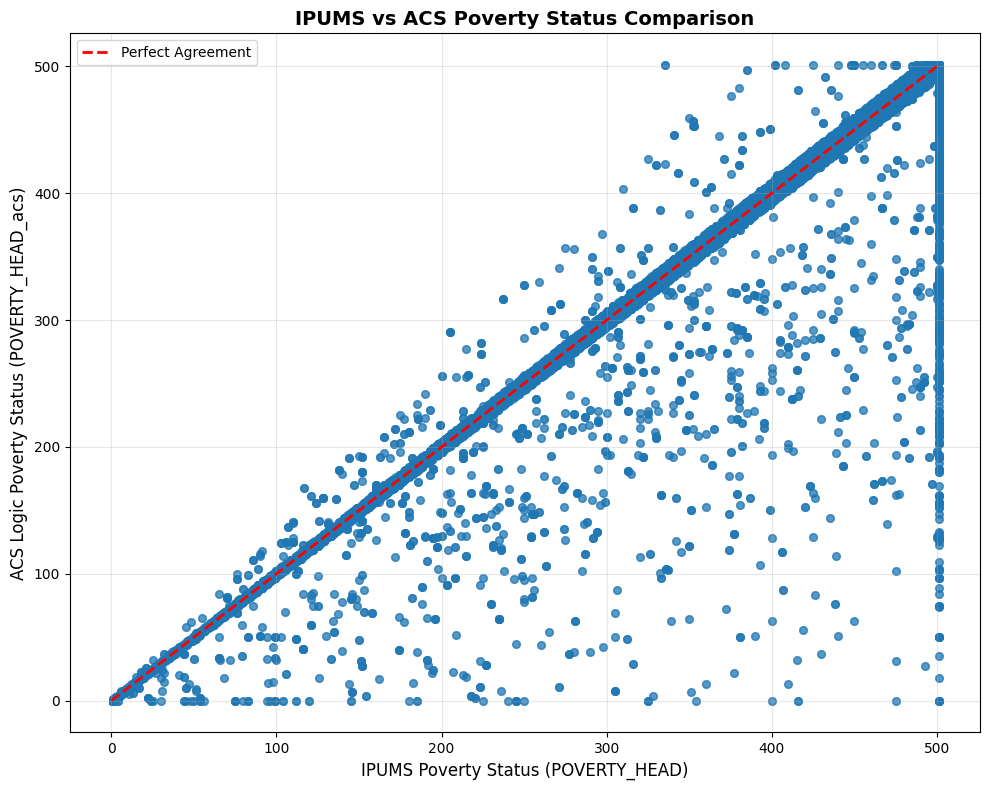

In [267]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 8))
plt.scatter(df_mass_pov_head_merged['POVERTY_HEAD'], 
           df_mass_pov_head_merged['POVERTY_HEAD_acs'], 
           alpha=0.5, s=30)

# Perfect agreement line
min_val = min(df_mass_pov_head_merged['POVERTY_HEAD'].min(), 
              df_mass_pov_head_merged['POVERTY_HEAD_acs'].min())
max_val = max(df_mass_pov_head_merged['POVERTY_HEAD'].max(), 
              df_mass_pov_head_merged['POVERTY_HEAD_acs'].max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Agreement')
plt.xlabel('IPUMS Poverty Status (POVERTY_HEAD)', fontsize=12)
plt.ylabel('ACS Logic Poverty Status (POVERTY_HEAD_acs)', fontsize=12)
plt.title('IPUMS vs ACS Poverty Status Comparison', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

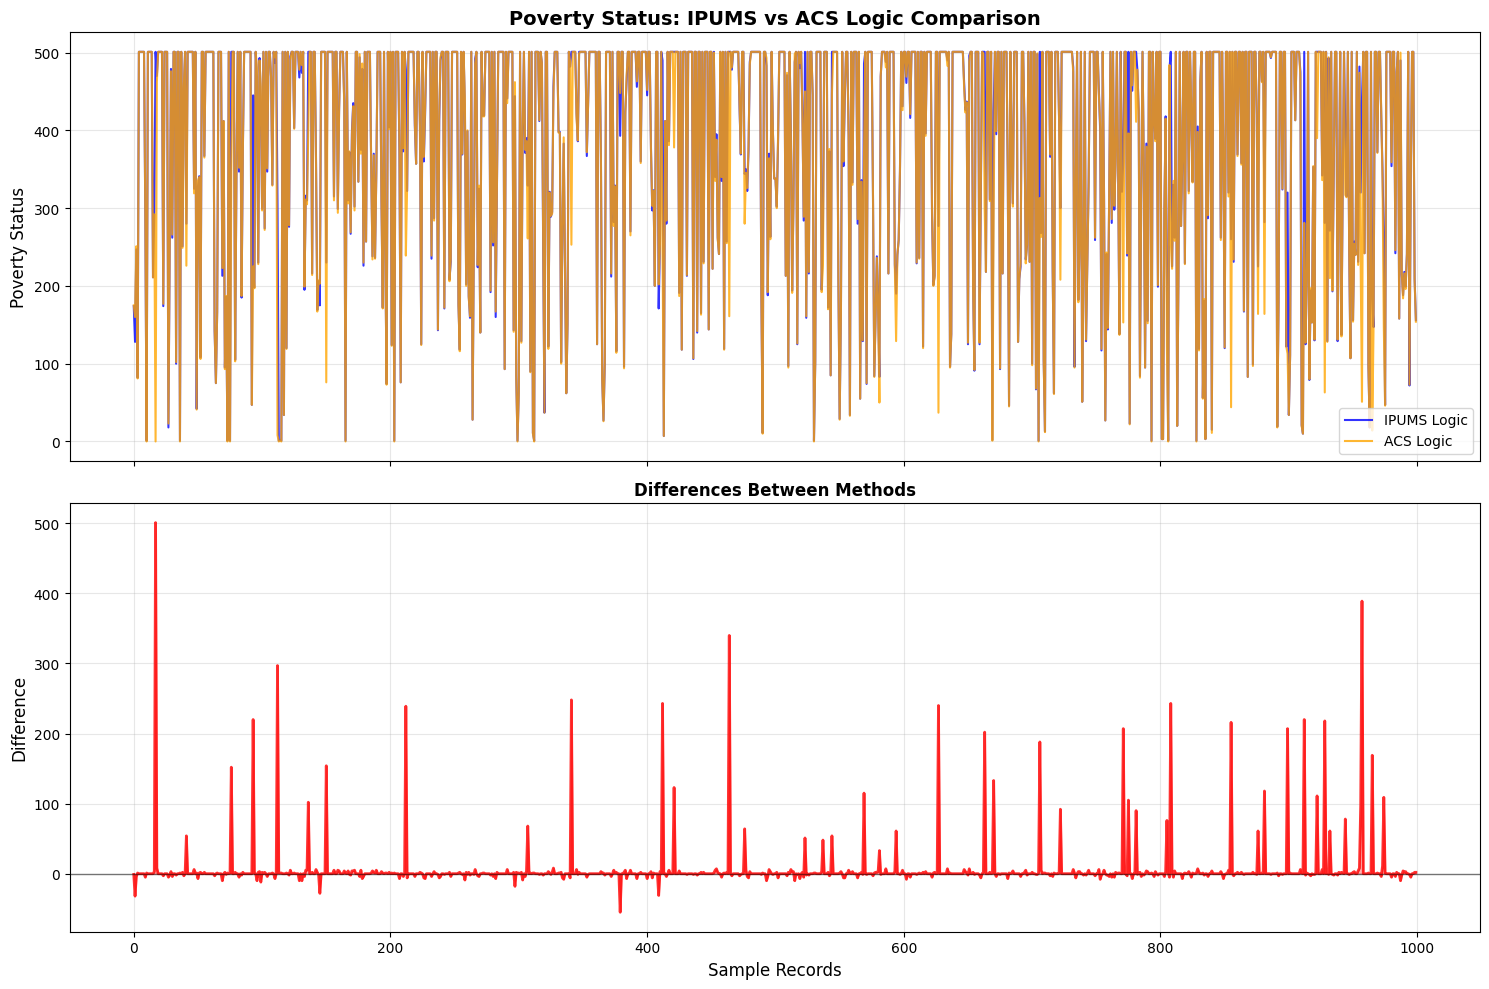

In [272]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Subplot 1: Both poverty measures
sample_size = min(1000, len(df_mass_pov_head_merged))  # Sample for readability
sample_data = df_mass_pov_head_merged.sample(sample_size).sort_index()

ax1.plot(range(len(sample_data)), sample_data['POVERTY_HEAD'], 
         label='IPUMS Logic', linewidth=1.5, alpha=0.8, color='blue')
ax1.plot(range(len(sample_data)), sample_data['POVERTY_HEAD_acs'], 
         label='ACS Logic', linewidth=1.5, alpha=0.8, color='orange')
ax1.set_title('Poverty Status: IPUMS vs ACS Logic Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Poverty Status', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Differences
ax2.plot(range(len(sample_data)), sample_data['pov_head_diff'], 
         linewidth=2, color='red', alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.fill_between(range(len(sample_data)), sample_data['pov_head_diff'], 0, 
                 alpha=0.3, color='red')
ax2.set_title('Differences Between Methods', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sample Records', fontsize=12)
ax2.set_ylabel('Difference', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [171]:
merged_ma['GCR'].unique()

array([nan,  2.,  1.])

In [207]:
def get_gcrespon_head_acs(df):
    result_df = df.copy()
    result_df['RESPON_HEAD_acs'] = 0
    for serialno, household in df.groupby('SERIALNO'):
        household_mask = (result_df['SERIALNO'] == serialno)
        head_records = household[household['RELSHIPP'] == 20]
        if head_records.empty:
            continue
        gcr_head = head_records['GCR'].values[0]
        # 1: Yes, 2: No for acs
        # 1: No, 2: Yes for ipums
        flipped_gcr_head = 3 - gcr_head
        # print(type(gcr_head))
        if np.isnan(gcr_head):
            # print(gcr_head)
            flipped_gcr_head = 0
        result_df.loc[household_mask, 'RESPON_HEAD_acs'] = flipped_gcr_head
    return result_df

In [208]:
res_gcrespon_head_df = gcrespon_head_acs(merged_ma_hu)

In [209]:
res_gcrespon_head_df.loc[res_gcrespon_head_df['SERIALNO_NEW'] == 2023001459883][['SERIALNO_NEW', 'SPORDER', 'GCR', 'RESPON_HEAD_acs']]

,SERIALNO_NEW,SPORDER,GCR,RESPON_HEAD_acs
73118,2023001459883,1,NaN,0
73119,2023001459883,2,NaN,0
73120,2023001459883,3,NaN,0
73121,2023001459883,4,NaN,0
73122,2023001459883,5,NaN,0
73123,2023001459883,6,NaN,0


In [180]:
def get_gcrepon_head(row, df):
    head = df[(df['SERIAL'] == row['SERIAL']) & (df['RELATE'] == 1)]
    if not head.empty:
        if head.iloc[0]['GCRESPON'] == 2:
            return 2
        elif head.iloc[0]['GCRESPON'] == 1:
            return 1
        else:
            return 0
        
ipums_molly['GCRESPON_HEAD']

0        0
1        0
2        0
3        0
4        0
        ..
67981    0
67982    0
67983    0
67984    0
67985    0
Name: GCRESPON_HEAD, Length: 67986, dtype: int64

In [210]:
ipums_molly_merged_gcrespon = pd.merge(ipums_molly,
                        res_gcrespon_head_df,
                        left_on=['CBSERIAL', 'PERNUM'],
                        right_on=['SERIALNO_NEW', 'SPORDER'],
                        how='inner')
ipums_molly_merged_gcrespon

,YEAR,SAMPLE,SERIAL,CBSERIAL,NUMPREC,HHWT,CLUSTER,STATEFIP,COUNTYFIP,PUMA,...,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80,SERIALNO_NEW,RESPON_HEAD_acs
0,2023,202301,653576,2023000000043,1,47.0,2023006535761,25,17,604,...,14,43,76,14,13,76,51,81,2023000000043,0
1,2023,202301,653577,2023000000074,1,93.0,2023006535771,25,21,904,...,95,29,25,144,87,167,94,91,2023000000074,0
2,2023,202301,653578,2023000000076,1,133.0,2023006535781,25,23,1103,...,254,254,161,228,127,247,123,195,2023000000076,0
3,2023,202301,653579,2023000000090,1,307.0,2023006535791,25,9,702,...,407,117,264,119,373,249,97,89,2023000000090,0
4,2023,202301,653580,2023000000123,1,278.0,2023006535801,25,25,804,...,276,85,235,394,102,112,418,107,2023000000123,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67981,2023,202301,682484,2023001459883,6,147.0,2023006824841,25,27,502,...,44,41,257,264,46,147,228,132,2023001459883,0
67982,2023,202301,682484,2023001459883,6,147.0,2023006824841,25,27,502,...,44,41,257,264,46,147,228,132,2023001459883,0
67983,2023,202301,682484,2023001459883,6,147.0,2023006824841,25,27,502,...,44,41,257,264,46,147,228,132,2023001459883,0
67984,2023,202301,682485,2023001459891,1,94.0,2023006824851,25,25,801,...,31,93,22,136,95,30,20,67,2023001459891,0


In [211]:
ipums_molly_merged_gcrespon.loc[ipums_molly_merged_gcrespon['GCRESPON_HEAD'] == ipums_molly_merged_gcrespon['RESPON_HEAD_acs']][['CBSERIAL', 'PERNUM', 'GCRESPON_HEAD', 'RESPON_HEAD_acs']]

,CBSERIAL,PERNUM,GCRESPON_HEAD,RESPON_HEAD_acs
0,2023000000043,1,0,0
1,2023000000074,1,0,0
2,2023000000076,1,0,0
3,2023000000090,1,0,0
4,2023000000123,1,0,0
...,...,...,...,...
67981,2023001459883,4,0,0
67982,2023001459883,5,0,0
67983,2023001459883,6,0,0
67984,2023001459891,1,0,0


In [213]:
"""
MOMRULE LOGIC:
direct link 1:-
    child relate == 25,26,27, parent relate == 20
    child relate == 20, parent relate == 29
    child relate == 28, parent relate == 29
    child relate == 21,23, parent relate == 31
2nd level link:-
    child relate == 30, parent relate == 25,26,27
    # Cousin to Aunt/Uncle, Parent to Grandparent, Sibling-in-law to Parent-in-law link cant do in acs
    child relate == 25,26,27, parent relate == 21,22,23,24 (spouse, partner)
3rd level link:-
    child relate == 30 to parent relate == 32
    child relate == 33 to parent relate == 28
    child relate == 34 to parent relate == 34
    child relate == 36 to parent relate == 22,24,36

Clarity level:-
    
"""

'\nsdaa\n'

In [ ]:
ipums_four = pd.read_csv('usa_00005.csv')
ipums_four_ma = ipums_four[ipums_four['STATEICP'] == 3]


array([ 0,  1,  2,  5,  3,  7,  6,  4,  8, 10,  9], dtype=int64)

In [223]:
ipums_four_ma.loc[ipums_four_ma['CBSERIAL'] == 2023001459883][['CBSERIAL', 'MOMRULE', 'MOMLOC', 'RELATE', 'PERNUM', 'SEX', 'AGE']]

,CBSERIAL,MOMRULE,MOMLOC,RELATE,PERNUM,SEX,AGE
1540519,2023001459883,0,0,1,1,2,40
1540520,2023001459883,11,1,3,2,2,15
1540521,2023001459883,11,1,3,3,2,15
1540522,2023001459883,0,0,7,4,2,34
1540523,2023001459883,34,4,10,5,2,8
1540524,2023001459883,0,0,12,6,1,21


In [ ]:
ipums_four_ma.groupby('CBSERIAL')

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STATEFIP,STRATA,GQ,...,SPRULE,MOMLOC2,MOM2RULE,POPLOC2,POP2RULE,NCHILD,RELATE,RELATED,SEX,AGE
1467401,2023,202301,648436,2023010000077,11.0,2023006484361,3,25,50325,4,...,0,0,0,0,0,0,12,1270,2,89
1467402,2023,202301,648437,2023010000098,11.0,2023006484371,3,25,61325,4,...,0,0,0,0,0,0,12,1270,1,20
1467403,2023,202301,648438,2023010000109,80.0,2023006484381,3,25,61325,3,...,0,0,0,0,0,0,13,1301,1,68
1467404,2023,202301,648439,2023010000114,69.0,2023006484391,3,25,80125,4,...,0,0,0,0,0,0,12,1270,2,21
1467405,2023,202301,648440,2023010000135,27.0,2023006484401,3,25,120125,4,...,0,0,0,0,0,0,12,1270,2,84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1540521,2023,202301,682484,2023001459883,147.0,2023006824841,3,25,50225,1,...,0,0,0,0,0,0,3,301,2,15
1540522,2023,202301,682484,2023001459883,147.0,2023006824841,3,25,50225,1,...,0,0,0,0,0,1,7,701,2,34
1540523,2023,202301,682484,2023001459883,147.0,2023006824841,3,25,50225,1,...,0,0,0,0,0,0,10,1001,2,8
1540525,2023,202301,682485,2023001459891,94.0,2023006824851,3,25,80125,1,...,0,0,0,0,0,0,1,101,2,24


In [260]:
def derive_pop_loc_head(df):
    """
    Fixed version that uses the input dataframe parameter correctly
    """
    # Create a copy to avoid modifying original data
    result_df = df.copy()  # Use df parameter, not hardcoded merged_ma
    
    # Initialize MOM_LOC_HEAD column
    result_df['POPLOC_HEAD_acs'] = None
    
    # Group by household (SERIALNO)
    for serialno, household in df.groupby('SERIALNO'):
        
        # Step 1: Find head of household (RELSHIPP == 20)
        head_records = household[household['RELSHIPP'] == 20]
        
        if len(head_records) == 0:
            # No head of household found, skip this household
            continue
        
        # Take first head if multiple (shouldn't happen in clean data)
        head = head_records.iloc[0]
        head_age = head['AGEP']
        head_sporder = head['SPORDER']
        
        # Step 3: Find mother candidates in same household
        candidates = household[
            (household['SEX'] == 1) # &  # Female
            # (household['AGEP'] <= head_age - 12)  # At least 12 years older than head
        ]
        
        if len(candidates) == 0:
            # No candidates found
            mom_sporder = 0
        else:
            # Step 4: Prioritize RELSHIPP == 29 (mother)
            mother_candidates = candidates[candidates['RELSHIPP'] == 29]
            
            if len(mother_candidates) > 0:
                # Found mother relationship, take first one
                mom_sporder = mother_candidates.iloc[0]['SPORDER']
            else:
                # No mother relationship found, take first candidate that fits age/sex criteria
                mom_sporder = 0
        
        # Assign MOM_LOC_HEAD to the head of household record
        household_mask = (result_df['SERIALNO'] == serialno) 
        result_df.loc[household_mask, 'POPLOC_HEAD_acs'] = mom_sporder
    
    return result_df

# Run the function on your merged dataset
print("Processing MOM_LOC_HEAD...")
result_data_poploc = derive_pop_loc_head(merged_ma_hu) 


Processing MOM_LOC_HEAD...


In [259]:
def get_poploc_head(row, df):
    head = df[(df['SERIAL'] == row['SERIAL']) & (df['RELATE'] == 1)]
    if not head.empty:
        return int(head.iloc[0]['POPLOC'])
    return None

# df_mass = df[df['STATEICP'] == 3]
df_mass['POPLOC_HEAD'] = df_mass.apply(lambda row: get_poploc_head(row, df_mass), axis=1)
df_mass 

C:\Users\91704\AppData\Local\Temp/ipykernel_5588/536608402.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mass['POPLOC_HEAD'] = df_mass.apply(lambda row: get_poploc_head(row, df_mass), axis=1)


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,POPLOC,SPLOC,NCHILD,RELATE,RELATED,SEX,AGE,POVERTY,CBPOVERTY,POPLOC_HEAD
1467401,2023,202301,648436,2023010000077,11.0,2023006484361,3,50325,4,1,...,0,0,0,12,1270,2,89,0,9,NaN
1467402,2023,202301,648437,2023010000098,11.0,2023006484371,3,61325,4,1,...,0,0,0,12,1270,1,20,0,0,NaN
1467403,2023,202301,648438,2023010000109,80.0,2023006484381,3,61325,3,1,...,0,0,0,13,1301,1,68,0,0,NaN
1467404,2023,202301,648439,2023010000114,69.0,2023006484391,3,80125,4,1,...,0,0,0,12,1270,2,21,0,0,NaN
1467405,2023,202301,648440,2023010000135,27.0,2023006484401,3,120125,4,1,...,0,0,0,12,1270,2,84,0,44,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1540522,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,4,...,0,0,1,7,701,2,34,365,365,0.0
1540523,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,5,...,0,0,0,10,1001,2,8,365,365,0.0
1540524,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,6,...,0,0,0,12,1260,1,21,225,225,0.0
1540525,2023,202301,682485,2023001459891,94.0,2023006824851,3,80125,1,1,...,0,0,0,1,101,2,24,77,78,0.0


In [261]:
df_mass_res_poploc_merge = pd.merge(df_mass,
                        result_data_poploc,
                        left_on=['CBSERIAL', 'PERNUM', 'SEX'],
                        right_on=['SERIALNO_NEW', 'SPORDER', 'SEX'],
                        how='inner')
df_mass_res_poploc_merge

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80,SERIALNO_NEW,POPLOC_HEAD_acs
0,2023,202301,653576,2023000000043,47.0,2023006535761,3,60425,1,1,...,14,43,76,14,13,76,51,81,2023000000043,0
1,2023,202301,653577,2023000000074,93.0,2023006535771,3,90425,1,1,...,95,29,25,144,87,167,94,91,2023000000074,0
2,2023,202301,653578,2023000000076,133.0,2023006535781,3,110325,1,1,...,254,254,161,228,127,247,123,195,2023000000076,0
3,2023,202301,653579,2023000000090,307.0,2023006535791,3,70225,1,1,...,407,117,264,119,373,249,97,89,2023000000090,0
4,2023,202301,653580,2023000000123,278.0,2023006535801,3,80425,1,1,...,276,85,235,394,102,112,418,107,2023000000123,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67981,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,4,...,44,41,257,264,46,147,228,132,2023001459883,0
67982,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,5,...,44,41,257,264,46,147,228,132,2023001459883,0
67983,2023,202301,682484,2023001459883,147.0,2023006824841,3,50225,1,6,...,44,41,257,264,46,147,228,132,2023001459883,0
67984,2023,202301,682485,2023001459891,94.0,2023006824851,3,80125,1,1,...,31,93,22,136,95,30,20,67,2023001459891,0


In [262]:
df_mass_res_poploc_merge.loc[df_mass_res_poploc_merge['POPLOC_HEAD_acs'] == df_mass_res_poploc_merge['POPLOC_HEAD']][['CBSERIAL', 'PERNUM', 'POPLOC_HEAD_acs', 'POPLOC_HEAD', 'RELATE', 'SEX', 'RELATED']]

,CBSERIAL,PERNUM,POPLOC_HEAD_acs,POPLOC_HEAD,RELATE,SEX,RELATED
0,2023000000043,1,0,0.0,1,2,101
1,2023000000074,1,0,0.0,1,2,101
2,2023000000076,1,0,0.0,1,1,101
3,2023000000090,1,0,0.0,1,2,101
4,2023000000123,1,0,0.0,1,1,101
...,...,...,...,...,...,...,...
67981,2023001459883,4,0,0.0,7,2,701
67982,2023001459883,5,0,0.0,10,2,1001
67983,2023001459883,6,0,0.0,12,1,1260
67984,2023001459891,1,0,0.0,1,2,101


In [263]:
df_mass_res_poploc_merge.loc[df_mass_res_poploc_merge['POPLOC_HEAD_acs'] != df_mass_res_poploc_merge['POPLOC_HEAD']][['CBSERIAL', 'PERNUM', 'POPLOC_HEAD_acs', 'POPLOC_HEAD', 'RELATE', 'SEX', 'RELATED']].to_csv('temp_poploc.csv')